# GenomeDISCO Analysis: Input, CNN, and HiCFoundation Decoder Variants

Compare GenomeDISCO reproducibility scores across all models.

In [1]:
import os
import sys

sys.path.insert(0, os.path.join("..", "..", "src"))

import numpy as np
import torch
from tqdm import tqdm

from hic_dataset import SubmatrixDataset
from hic_model import SimpleEnhanceCNN, HiCFoundationHead
from hic_train import (
    compute_genomedisco,
    compute_genomedisco_scores,
    load_or_compute_scores,
    plot_ssim_violin_5way,
    plot_score_scatter,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

test_dataset = SubmatrixDataset(os.path.join("..", "..", "results", "submatrices", "frac_0.05", "test.h5"))
print(f"Test dataset size: {len(test_dataset)}")

cache_dir = os.path.join("..", "..", "results", "score_cache")

Using device: cuda
Test dataset size: 5026


In [2]:
# Compute GenomeDISCO for input vs target (baseline)
def compute_input_genomedisco(dataset):
    scores = []
    for idx in tqdm(range(len(dataset)), desc="Input GenomeDISCO", total=len(dataset)):
        x, y = dataset[idx]
        x_np = np.clip(x[0].numpy(), 0, None)
        y_np = np.clip(y[0].numpy(), 0, None)
        scores.append(compute_genomedisco(x_np, y_np))
    return np.array(scores)

input_gdisco = load_or_compute_scores(
    os.path.join(cache_dir, "gdisco_input.npz"),
    compute_input_genomedisco, test_dataset
)
print(f"Input GenomeDISCO: mean={input_gdisco.mean():.4f}, std={input_gdisco.std():.4f}")


Loading cached scores from ..\results\score_cache\gdisco_input.npz
Input GenomeDISCO: mean=0.8179, std=0.0429


In [3]:
# Load CNN model and compute GenomeDISCO
cnn_run_date = "2026-07-30"
cnn_model_path = os.path.join("..", "..", "results", "training", cnn_run_date, "model.pt")

cnn_model = SimpleEnhanceCNN()
cnn_model.load_state_dict(torch.load(cnn_model_path, map_location=device))
cnn_model.to(device).eval()

cnn_gdisco = load_or_compute_scores(
    os.path.join(cache_dir, "gdisco_cnn.npz"),
    compute_genomedisco_scores, cnn_model, test_dataset, device
)
print(f"CNN GenomeDISCO: mean={cnn_gdisco.mean():.4f}, std={cnn_gdisco.std():.4f}")


Loading cached scores from ..\results\score_cache\gdisco_cnn.npz
CNN GenomeDISCO: mean=0.8352, std=0.0466


C:\Users\momoh\AppData\Local\Temp\ipykernel_44516\1901377004.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  cnn_model.load_state_dict(torch.load(cnn_model_path, map_loc

In [4]:
# Load HiCFoundation models (1, 4, 8 layer)
hicf_run_date = "2026-08-11"
hicf_weights = os.path.join("..", "..", "hicfoundation_model", "hicfoundation_pretrain.pth.tar")

hicf_gdisco = {}

for layers in [1, 4, 8]:
    model_path = os.path.join("..", "..", "results", f"training_hicfoundation_{layers}layer", hicf_run_date, "model.pt")

    model = HiCFoundationHead(hicf_weights, decoder_layers=layers)
    state_dict = torch.load(model_path, map_location=device)

    if any(k.startswith("_orig_mod.") for k in state_dict.keys()):
        state_dict = {k.replace("_orig_mod.", ""): v for k, v in state_dict.items()}

    model.load_state_dict(state_dict, strict=False)
    model.to(device).eval()

    hicf_gdisco[layers] = load_or_compute_scores(
        os.path.join(cache_dir, f"gdisco_hicf_{layers}layer.npz"),
        compute_genomedisco_scores, model, test_dataset, device
    )
    print(f"HiCFoundation {layers}-layer: mean={hicf_gdisco[layers].mean():.4f}, std={hicf_gdisco[layers].std():.4f}")

print("\nAll models scored")

C:\Users\momoh\AppData\Local\Temp\ipykernel_44516\4038514506.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(model_path, map_location=device)


No cache at ..\results\score_cache\gdisco_hicf_1layer.npz -- computing...


Computing GenomeDISCO scores: 100%|██████████| 79/79 [12:49<00:00,  9.74s/it]


Saved scores to ..\results\score_cache\gdisco_hicf_1layer.npz
HiCFoundation 1-layer: mean=0.8454, std=0.0413
No cache at ..\results\score_cache\gdisco_hicf_4layer.npz -- computing...


Computing GenomeDISCO scores: 100%|██████████| 79/79 [07:13<00:00,  5.49s/it]


Saved scores to ..\results\score_cache\gdisco_hicf_4layer.npz
HiCFoundation 4-layer: mean=0.8470, std=0.0428
No cache at ..\results\score_cache\gdisco_hicf_8layer.npz -- computing...


Computing GenomeDISCO scores: 100%|██████████| 79/79 [07:15<00:00,  5.51s/it]

Saved scores to ..\results\score_cache\gdisco_hicf_8layer.npz
HiCFoundation 8-layer: mean=0.8474, std=0.0430

All models scored


In [5]:
# Compile all scores for comparison
all_scores_gd = {
    "Input": input_gdisco,
    "CNN": cnn_gdisco,
    "HiCFoundation (1-layer)": hicf_gdisco[1],
    "HiCFoundation (4-layer)": hicf_gdisco[4],
    "HiCFoundation (8-layer)": hicf_gdisco[8],
}

print("\n" + "="*60)
print("GenomeDISCO Summary Statistics (mean ± std)")
print("="*60)
for label, scores in all_scores_gd.items():
    print(f"{label:30s}: {scores.mean():.4f} ± {scores.std():.4f}")
print("="*60)


GenomeDISCO Summary Statistics (mean ± std)
Input                         : 0.8179 ± 0.0429
CNN                           : 0.8352 ± 0.0466
HiCFoundation (1-layer)       : 0.8454 ± 0.0413
HiCFoundation (4-layer)       : 0.8470 ± 0.0428
HiCFoundation (8-layer)       : 0.8474 ± 0.0430


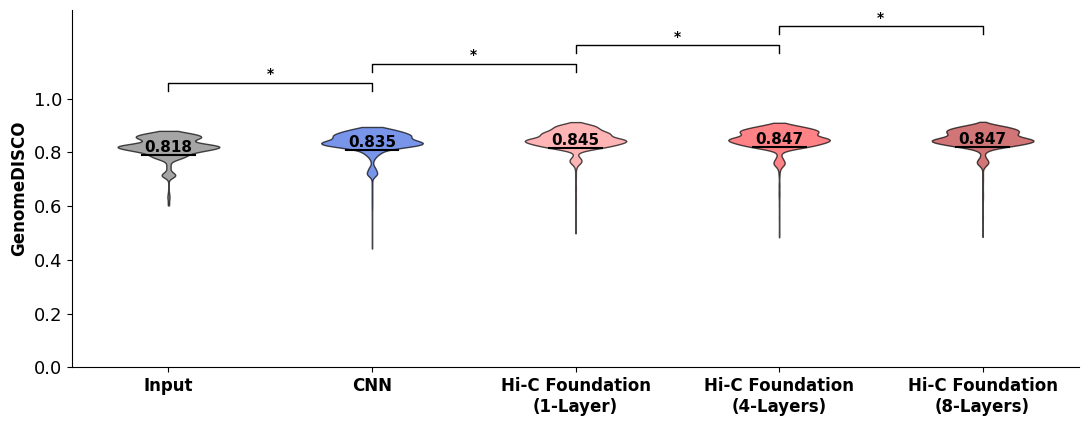

Violin plot saved


In [6]:
# Create violin plot comparing all models
comparison_dir = os.path.join("..", "..", "results", "plots", "gdisco_analysis")
os.makedirs(comparison_dir, exist_ok=True)

plot_ssim_violin_5way(
    all_scores_gd,
    metric_name="GenomeDISCO",
    save_path=os.path.join(comparison_dir, "violin_plot_all_models.png"),
    pairs=[
        ("Input", "CNN"),
        ("CNN", "HiCFoundation (1-layer)"),
        ("HiCFoundation (1-layer)", "HiCFoundation (4-layer)"),
        ("HiCFoundation (4-layer)", "HiCFoundation (8-layer)")
    ]
)
print("Violin plot saved")


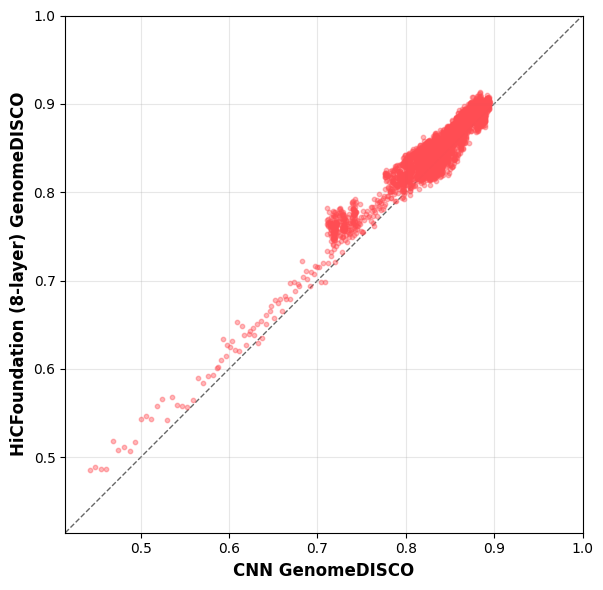

Scatter plot (CNN vs 8-layer) saved


In [7]:
# Scatter plot: CNN vs 8-layer HiCFoundation
best_hicf = hicf_gdisco[8]

plot_score_scatter(
    cnn_gdisco, best_hicf,
    label_x="CNN", label_y="HiCFoundation (8-layer)",
    metric_name="GenomeDISCO",
    save_path=os.path.join(comparison_dir, "scatter_cnn_vs_hicf_8layer.png")
)
print("Scatter plot (CNN vs 8-layer) saved")


In [8]:
# Summary comparison between 1-layer HiCF (best model) and CNN
print("\n" + "="*60)
print("Best Model Comparison: CNN vs HiCFoundation (8-layer)")
print("="*60)
print(f"CNN:                  mean={cnn_gdisco.mean():.4f} ± {cnn_gdisco.std():.4f}")
print(f"HiCF (8-layer):       mean={best_hicf.mean():.4f} ± {best_hicf.std():.4f}")
print(f"Difference (HiCF - CNN): {(best_hicf.mean() - cnn_gdisco.mean()):.4f}")

better_count = (best_hicf > cnn_gdisco).sum()
pct_better = 100 * better_count / len(best_hicf)
print(f"Windows where HiCF > CNN: {better_count}/{len(best_hicf)} ({pct_better:.1f}%)")
print("="*60)

test_dataset.close()


Best Model Comparison: CNN vs HiCFoundation (8-layer)
CNN:                  mean=0.8352 ± 0.0466
HiCF (8-layer):       mean=0.8474 ± 0.0430
Difference (HiCF - CNN): 0.0122
Windows where HiCF > CNN: 4234/5026 (84.2%)
